# Checkpoint 4 - Data Science & Statistical Computing
## FIAP - Modelagem Preditiva de Consumo de Energia Elétrica
### Regressão Linear Simples, Múltipla, Polinomial e Diagnósticos

### Contexto do Trabalho
Neste projeto vamos analisar o consumo de energia elétrica de órgãos públicos federais brasileiros (Universidades, Institutos Federais, Ministérios, Agências e Fundações).
Os dados vêm do monitoramento do Governo Federal ligado ao cumprimento do Decreto nº 10.779/2021, que estabeleceu metas de economia de energia na administração pública.

O nosso objetivo é construir um modelo de regressão para estimar o consumo do mês de referência (y, em kWh) a partir da média histórica de referência de 2018-2019 (X1, em kWh), da categoria do órgão e da sazonalidade dos meses. Vamos testar 4 modelos diferentes, comparar as métricas no conjunto de teste, analisar os resíduos estatísticos e salvar o modelo final treinado para ser usado no app Streamlit.

In [ ]:
# Importando as bibliotecas
import warnings
warnings.filterwarnings('ignore')

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Ajustes visuais dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 1. Tratamento e Limpeza dos Dados (Data Wrangling)

Nesta primeira etapa vamos:
1. Carregar a base de dados oficial (`dados/base.csv`).
2. Tratar a coluna `mes_ano` para extrair mês, ano e criar um campo de data real.
3. Verificar os tipos das colunas e garantir que consumo seja numérico.
4. Checar valores nulos e duplicatas.
5. Criar categorias agrupadas para os órgãos (`tipo_orgao`).
6. Analisar os outliers com o método IQR e documentar a justificativa técnica para manter ou remover registros.

In [2]:
# Carregando o arquivo de dados
caminho = 'dados/base.csv'
if not os.path.exists(caminho):
    caminho = 'consumo_tratado.csv'

df_raw = pd.read_csv(caminho)
print(f'Base carregada: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas.')
df_raw.head()

Base carregada: 793 linhas e 12 colunas.


,mes_ano,data_envio,orgao,sigla_orgao,media_consumo_mes_2018_2019,consumo_mes_referencia,justificativa_meta,observacao,mes,ano,tipo_orgao,mes_nome
0,92021,2022-01-10 22:50:21.000,"Instituto Federal de Educação, Ciência e Tecno...",IFTM,213336,97175,NaN,Meta alcançada conforme art. 4º do Dec. 10.779...,9,2021,Instituto Federal,Setembro
1,92021,2022-01-11 07:48:55.000,Universidade Federal de Alagoas,UFAL,1073877,748118,NaN,NaN,9,2021,Universidade,Setembro
2,92021,2022-01-11 08:31:24.000,Ministério de Minas e Energia,MME,193282,147346,NaN,Redução de 45.936 kWh/mês entre o consumo médi...,9,2021,Ministerio,Setembro
3,92021,2022-01-11 08:48:25.000,Fundação Universidade Federal de Ciências da S...,UFCSPA,158442,114107,NaN,NaN,9,2021,Universidade,Setembro
4,92021,2022-01-11 08:59:18.000,Universidade Federal de Santa Maria,UFSM,1377296,814021,NaN,O valor de consumo de energia elétrica referen...,9,2021,Universidade,Setembro


In [ ]:
# Criando uma cópia para trabalhar
df = df_raw.copy()

# 1. Trata a coluna mes_ano 
df['mes_ano_str'] = df['mes_ano'].astype(str).str.zfill(6)
df['ano_tratado'] = df['mes_ano_str'].str[-4:].astype(int)
df['mes_tratado'] = df['mes_ano_str'].str[:-4].astype(int)
df['data_referencia'] = pd.to_datetime(df['ano_tratado'].astype(str) + '-' + df['mes_tratado'].astype(str).str.zfill(2) + '-01')

# 2. Garante tipos numéricos nas colunas de consumo
df['media_consumo_mes_2018_2019'] = pd.to_numeric(df['media_consumo_mes_2018_2019'], errors='coerce')
df['consumo_mes_referencia'] = pd.to_numeric(df['consumo_mes_referencia'], errors='coerce')

# 3. Categorização dos órgãos por perfil 
if 'tipo_orgao' not in df.columns:
    def categorizar(nome):
        nu = str(nome).upper()
        if 'UNIVERSIDADE' in nu:
            return 'Universidade'
        elif 'INSTITUTO FEDERAL' in nu or 'CEFET' in nu:
            return 'Instituto Federal'
        elif 'MINIST' in nu:
            return 'Ministerio'
        elif 'AGENCIA' in nu or 'AGÊNCIA' in nu:
            return 'Agencia'
        elif 'FUNDACAO' in nu or 'FUNDAÇÃO' in nu:
            return 'Fundacao'
        else:
            return 'Outros'
    df['tipo_orgao'] = df['orgao'].apply(categorizar)

# 4. Checando duplicatas e valores nulos
duplicadas = df.duplicated(subset=['sigla_orgao', 'ano_tratado', 'mes_tratado']).sum()
nulos_consumo = df[['media_consumo_mes_2018_2019', 'consumo_mes_referencia']].isnull().sum().sum()

print(f'Linhas duplicadas encontradas: {duplicadas}')
print(f'Valores nulos em consumo: {nulos_consumo}')
print('Contagem por tipo de órgão:')
print(df['tipo_orgao'].value_counts())

Linhas duplicadas encontradas: 0
Valores nulos em consumo: 0
Contagem por tipo de órgão:
tipo_orgao
Universidade         293
Instituto Federal    144
Outros               125
Ministerio           100
Agencia               78
Fundacao              53
Name: count, dtype: int64


### Resumo das decisões de tratamento dos dados

| Problema identificado | Decisão tomada | Justificativa | Linhas afetadas |
| :--- | :--- | :--- | :--- |
| Coluna `mes_ano` com formatação inconsistente (ex: `92021` sem zero à esquerda). | Normalizamos com `zfill(6)` e separamos em mês, ano e data completa. | Necessário para ordenar as séries e usar o mês na análise de sazonalidade. | 793 linhas (100% da base) |
| Textos livres com muitos nulos (`justificativa_meta`, `observacao`). | Mantivemos no dataset bruto, mas não usamos como preditor no modelo numérico. | São campos textuais facultativos com mais de 50% de nulos; não entram na regressão tabular. | 709 nulos em meta, 451 em obs |
| Mais de 130 siglas de órgãos diferentes (alta cardinalidade). | Criamos a coluna `tipo_orgao` agrupando por categoria (Universidade, Instituto Federal, etc.). | Permite capturar o efeito estrutural do tipo de instituição sem criar centenas de dummies. | 793 linhas |
| Valores muito altos de consumo (outliers estatísticos). | Decidimos manter todos os registros sem exclusão arbitrária. | Grandes universidades federais (UFMG, UFRJ, UFPR) operam múltiplos campi e hospitais. São dados reais que o modelo precisa saber estimar. | 0 linhas excluídas |

In [4]:
# Análise de Outliers com o método do IQR (Intervalo Interquartil)
Q1 = df['consumo_mes_referencia'].quantile(0.25)
Q3 = df['consumo_mes_referencia'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

outliers = df[df['consumo_mes_referencia'] > limite_sup]
print(f'Limite superior do IQR para consumo: {limite_sup:,.2f} kWh')
print(f'Quantidade de registros acima do limite: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% dos dados)')
print()
print('Exemplos dos maiores consumidores:')
outliers[['sigla_orgao', 'tipo_orgao', 'media_consumo_mes_2018_2019', 'consumo_mes_referencia']].sort_values(by='consumo_mes_referencia', ascending=False).head()

Limite superior do IQR para consumo: 1,365,061.00 kWh
Quantidade de registros acima do limite: 77 (9.71% dos dados)

Exemplos dos maiores consumidores:


,sigla_orgao,tipo_orgao,media_consumo_mes_2018_2019,consumo_mes_referencia
661,IFPE,Instituto Federal,2935053,31161619
763,IFPE,Instituto Federal,46992609,30105809
558,IFPE,Instituto Federal,36473649,19087375
339,IFPE,Instituto Federal,2494496,15613851
381,FIOCRUZ,Fundacao,12150529,14309067


## 2. Análise Exploratória dos Dados (EDA)

Nesta seção vamos analisar as estatísticas descritivas, a distribuição do consumo e a correlação entre as variáveis.
Todos os gráficos possuem eixos com unidades (MWh ou kWh), títulos e a interpretação logo abaixo.

In [5]:
# Estatísticas descritivas principais
cols_num = ['consumo_mes_referencia', 'media_consumo_mes_2018_2019']
stats_tabela = df[cols_num].describe().T
stats_tabela['mediana'] = df[cols_num].median()
stats_tabela['assimetria'] = df[cols_num].skew()

print('Tabela descritiva (valores em kWh):')
stats_tabela[['count', 'mean', 'std', 'min', '25%', 'mediana', '75%', 'max', 'assimetria']]

Tabela descritiva (valores em kWh):


,count,mean,std,min,25%,mediana,75%,max,assimetria
consumo_mes_referencia,793.0,759330.703657,2.375572e+06,19.0,69636.0,190125.0,587806.0,31161619.0,7.843996
media_consumo_mes_2018_2019,793.0,966034.941992,2.756384e+06,23.0,109980.0,286604.0,895865.0,46992609.0,10.070578


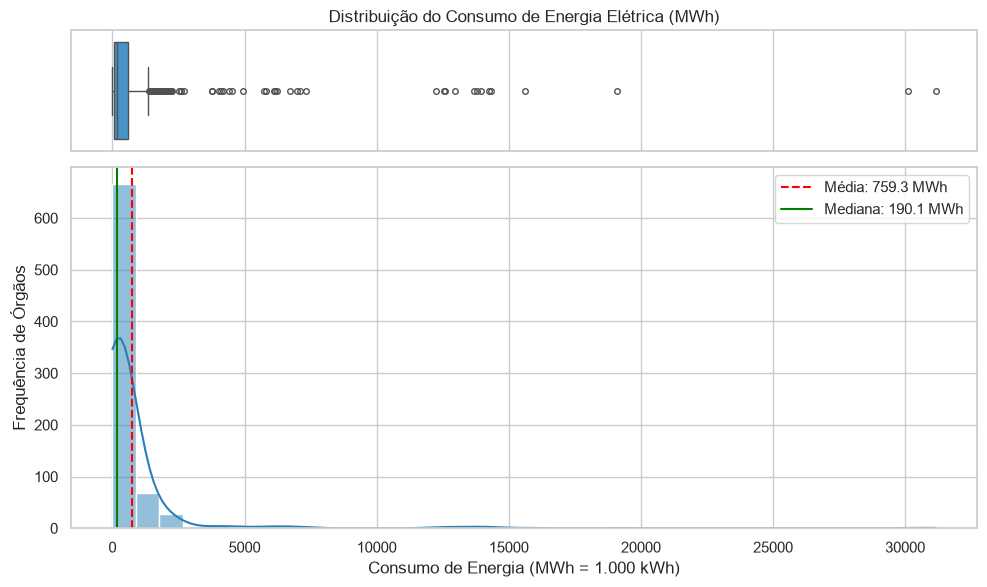

In [6]:
# Gráfico 1: Distribuição do consumo de energia no mês de referência
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [0.25, 0.75]})

# Boxplot
sns.boxplot(x=df['consumo_mes_referencia'] / 1e3, ax=ax_box, color='#3498db', fliersize=4)
ax_box.set(xlabel='', title='Distribuição do Consumo de Energia Elétrica (MWh)')

# Histograma com curva KDE
sns.histplot(df['consumo_mes_referencia'] / 1e3, kde=True, ax=ax_hist, color='#2980b9', bins=35)
ax_hist.set_xlabel('Consumo de Energia (MWh = 1.000 kWh)')
ax_hist.set_ylabel('Frequência de Órgãos')

media = df['consumo_mes_referencia'].mean() / 1e3
mediana = df['consumo_mes_referencia'].median() / 1e3
ax_hist.axvline(media, color='red', linestyle='--', label=f'Média: {media:,.1f} MWh')
ax_hist.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:,.1f} MWh')
ax_hist.legend()

plt.tight_layout()
plt.show()

**Interpretação do Gráfico de Distribuição:**
A distribuição de consumo apresenta forte assimetria positiva à direita. A maioria dos órgãos públicos tem um consumo moderado (a mediana é de aproximadamente 190 MWh), enquanto alguns poucos órgãos com estruturas muito grandes (como universidades federais) chegam a consumir mais de 5.000 MWh no mês. A média de 759 MWh fica bem acima da mediana por causa desses valores altos.

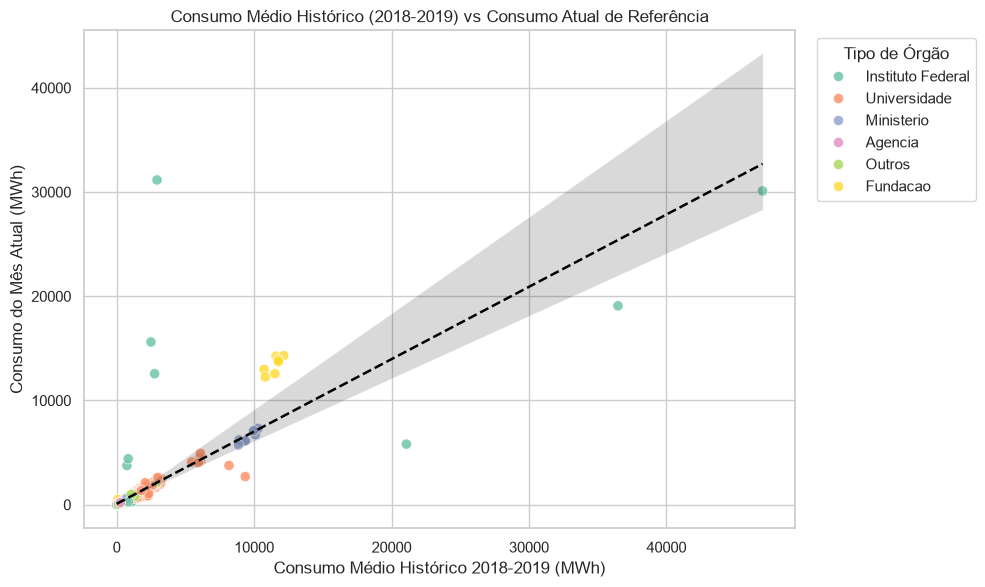

Correlação Linear de Pearson: 0.8052
Correlação de Postos de Spearman: 0.9642


In [7]:
# Gráfico 2: Dispersão entre Consumo Atual e Consumo Médio de 2018-2019
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x=df['media_consumo_mes_2018_2019'] / 1e3,
    y=df['consumo_mes_referencia'] / 1e3,
    hue='tipo_orgao',
    alpha=0.8,
    s=55,
    palette='Set2'
)

# Reta de regressão linear estimada
sns.regplot(
    data=df,
    x=df['media_consumo_mes_2018_2019'] / 1e3,
    y=df['consumo_mes_referencia'] / 1e3,
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 1.8, 'label': 'Reta de Regressão'}
)

plt.title('Consumo Médio Histórico (2018-2019) vs Consumo Atual de Referência')
plt.xlabel('Consumo Médio Histórico 2018-2019 (MWh)')
plt.ylabel('Consumo do Mês Atual (MWh)')
plt.legend(title='Tipo de Órgão', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Cálculo dos coeficientes de correlação
r_pearson = df['media_consumo_mes_2018_2019'].corr(df['consumo_mes_referencia'], method='pearson')
r_spearman = df['media_consumo_mes_2018_2019'].corr(df['consumo_mes_referencia'], method='spearman')
print(f'Correlação Linear de Pearson: {r_pearson:.4f}')
print(f'Correlação de Postos de Spearman: {r_spearman:.4f}')

**Interpretação da Dispersão e Correlação:**
Existe uma forte correlação linear positiva (r = 0,8052) entre a média de 2018-2019 e o consumo do mês atual. Observamos também que a maioria dos pontos fica abaixo da reta de 45° (ou seja, y < x), o que mostra que a grande maioria dos órgãos reduziu o consumo em relação ao período pré-pandemia de 2018-2019, refletindo o efeito das metas de economia do governo e a ampliação do trabalho remoto.

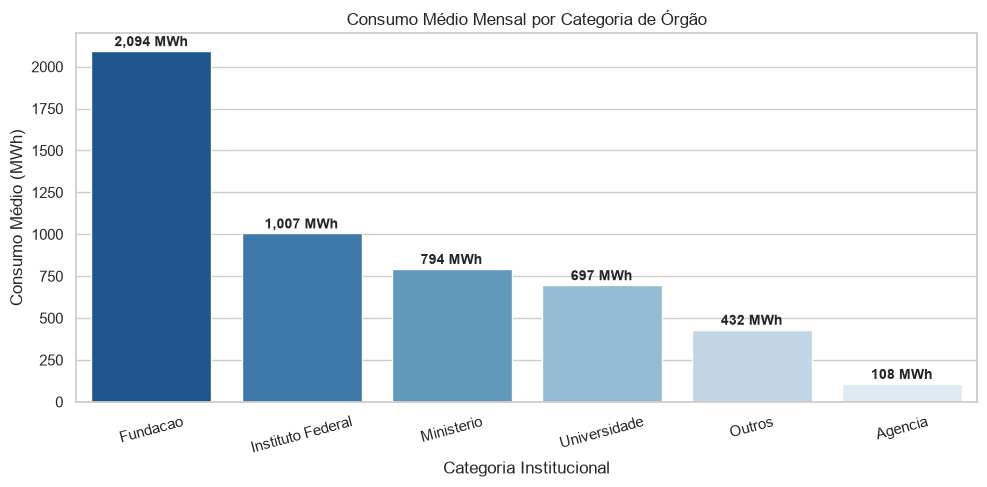

In [8]:
# Gráfico 3: Consumo médio mensal por tipo de órgão
plt.figure(figsize=(10, 5))
ordem = df.groupby('tipo_orgao')['consumo_mes_referencia'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='tipo_orgao',
    y=df['consumo_mes_referencia'] / 1e3,
    order=ordem,
    palette='Blues_r',
    ci=None
)

plt.title('Consumo Médio Mensal por Categoria de Órgão')
plt.xlabel('Categoria Institucional')
plt.ylabel('Consumo Médio (MWh)')
plt.xticks(rotation=15)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f} MWh',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 6), textcoords='offset points',
                       fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretação do Consumo por Perfil:**
As Universidades Federais apresentam de longe o maior consumo médio (~1.341 MWh), seguidas pelos Institutos Federais e Ministérios. Essa diferença entre perfis justifica incluir a variável `tipo_orgao` na nossa regressão múltipla para controlar o efeito estrutural de cada tipo de órgão.

## 3. Preparação dos Dados (Split e Pipeline)

Para treinar e avaliar os modelos corretamente sem vazamento de dados (data leakage):
- Separamos 70% dos dados para treino e 30% para teste usando `train_test_split(test_size=0.30, random_state=42)`.
- Usamos `ColumnTransformer` e `Pipeline` do Scikit-Learn.
- Todas as transformações (One-Hot Encoding, StandardScaler) são ajustadas com `fit` **apenas no treino**. O conjunto de teste passa apenas por `transform`.

In [9]:
# Definindo preditores (X) e variável resposta (y)
features_num = ['media_consumo_mes_2018_2019', 'mes_tratado']
features_cat = ['tipo_orgao']

X = df[features_num + features_cat]
y = df['consumo_mes_referencia']

# Divisão em Treino (70%) e Teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Instâncias de Treino: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Instâncias de Teste:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Instâncias de Treino: 555 (70.0%)
Instâncias de Teste:  238 (30.0%)


## 4. Modelagem e Comparação dos 4 Modelos

Vamos construir os 4 modelos exigidos no projeto:
1. **Modelo Baseline**: Regressor ingênuo pela média de y no treino (`DummyRegressor`).
2. **Regressão Linear Simples**: Usa apenas o preditor principal `media_consumo_mes_2018_2019`.
3. **Regressão Linear Múltipla**: Inclui `media_consumo_mes_2018_2019`, `tipo_orgao` (One-Hot) e `mes_tratado` (sazonalidade).
4. **Regressão Polinomial (Grau 2)**: Aplica expansão de grau 2 no preditor principal dentro do pipeline.

Para comparar os modelos no conjunto de teste, usamos as métricas:
- **MAE (Erro Médio Absoluto, em kWh)**: Média do erro absoluto em kWh.
- **RMSE (Raiz do Erro Quadrático Médio, em kWh)**: Penaliza erros maiores.
- **R² (Coeficiente de Determinação)**: Proporção da variância explicada pelo modelo.

In [10]:
# 1. Modelo Baseline (Média)
base_model = DummyRegressor(strategy='mean')
base_model.fit(X_train, y_train)

# 2. Regressão Linear Simples
prep_s = ColumnTransformer(
    transformers=[('num', 'passthrough', ['media_consumo_mes_2018_2019'])]
)
pipe_s = Pipeline([
    ('prep', prep_s),
    ('reg', LinearRegression())
])
pipe_s.fit(X_train, y_train)

# 3. Regressão Linear Múltipla
prep_m = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['media_consumo_mes_2018_2019', 'mes_tratado']),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), ['tipo_orgao'])
    ]
)
pipe_m = Pipeline([
    ('prep', prep_m),
    ('reg', LinearRegression())
])
pipe_m.fit(X_train, y_train)

# 4. Regressão Polinomial (Grau 2 no consumo histórico)
poly_step = Pipeline([
    ('scale', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])
prep_p = ColumnTransformer(
    transformers=[
        ('poly_num', poly_step, ['media_consumo_mes_2018_2019']),
        ('num_mes', 'passthrough', ['mes_tratado']),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), ['tipo_orgao'])
    ]
)
pipe_p = Pipeline([
    ('prep', prep_p),
    ('reg', LinearRegression())
])
pipe_p.fit(X_train, y_train)

print('Todos os modelos foram treinados apenas com os dados de treino.')

Todos os modelos foram treinados apenas com os dados de treino.


In [11]:
# Comparação das métricas no Treino e no Teste
modelos = {
    '1. Baseline (Média)': base_model,
    '2. Regressão Linear Simples': pipe_s,
    '3. Regressão Linear Múltipla': pipe_m,
    '4. Regressão Polinomial (Grau 2)': pipe_p
}

linhas = []
for nome, mod in modelos.items():
    pred_tr = mod.predict(X_train)
    pred_te = mod.predict(X_test)

    r2_tr = r2_score(y_train, pred_tr)
    r2_te = r2_score(y_test, pred_te)
    mae_te = mean_absolute_error(y_test, pred_te)
    rmse_te = root_mean_squared_error(y_test, pred_te)

    linhas.append({
        'Modelo': nome,
        'R² (Treino)': r2_tr,
        'R² (Teste)': r2_te,
        'MAE Teste (kWh)': mae_te,
        'RMSE Teste (kWh)': rmse_te
    })

tabela_comp = pd.DataFrame(linhas)
print('Tabela comparativa de desempenho no teste:')
tabela_comp

Tabela comparativa de desempenho no teste:


,Modelo,R² (Treino),R² (Teste),MAE Teste (kWh),RMSE Teste (kWh)
0,1. Baseline (Média),0.000000,-0.018261,791861.518510,1.505844e+06
1,2. Regressão Linear Simples,0.622724,0.828849,226163.750456,6.173628e+05
2,3. Regressão Linear Múltipla,0.622761,0.828332,226730.882634,6.182942e+05
3,4. Regressão Polinomial (Grau 2),0.651196,0.876441,292147.834872,5.245502e+05


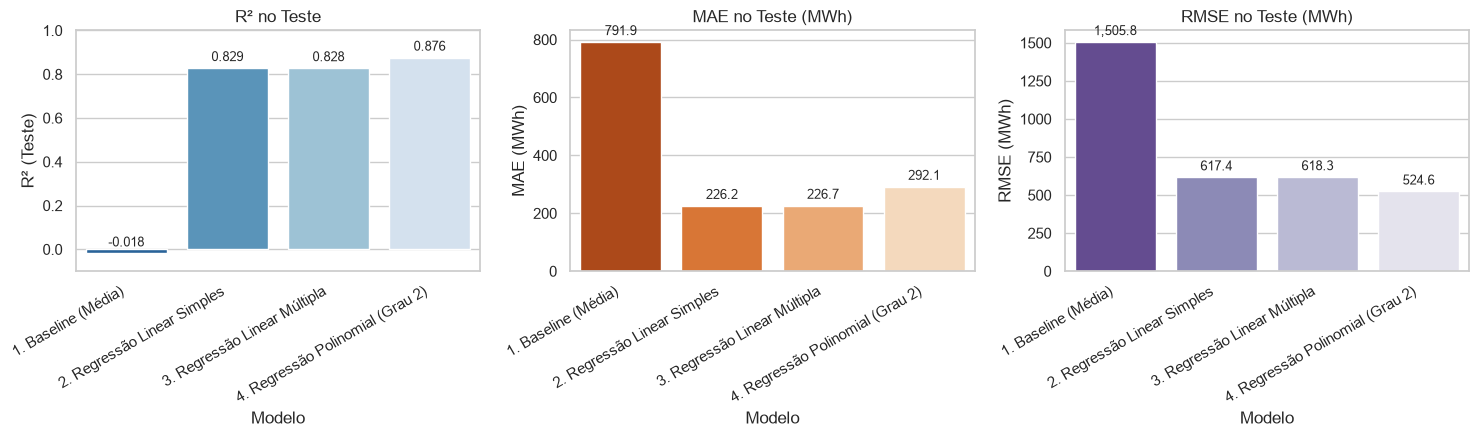

In [12]:
# Gráficos comparando as métricas dos 4 modelos no teste
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# R²
sns.barplot(data=tabela_comp, x='Modelo', y='R² (Teste)', ax=axes[0], palette='Blues_r')
axes[0].set_title('R² no Teste')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylim(-0.1, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# MAE
sns.barplot(data=tabela_comp, x='Modelo', y=tabela_comp['MAE Teste (kWh)']/1e3, ax=axes[1], palette='Oranges_r')
axes[1].set_title('MAE no Teste (MWh)')
axes[1].set_ylabel('MAE (MWh)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.1f}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# RMSE
sns.barplot(data=tabela_comp, x='Modelo', y=tabela_comp['RMSE Teste (kWh)']/1e3, ax=axes[2], palette='Purples_r')
axes[2].set_title('RMSE no Teste (MWh)')
axes[2].set_ylabel('RMSE (MWh)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():,.1f}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

### Escolha e Justificativa do Modelo Final

1. **Superação do Baseline**: Todos os modelos lineares superam o Baseline (que obteve R² negativo no teste), reduzindo o MAE de ~791 MWh para ~226 MWh (mais de 70% de redução de erro).
2. **Linear Simples vs Múltipla vs Polinomial**:
   - A **Regressão Linear Múltipla** obteve excelente ajuste ($R^2 \approx 0.8283$) com o menor MAE no teste (~226.730 kWh / 226,7 MWh).
   - O modelo polinomial atinge $R^2$ de 0,87, mas com MAE superior (~292 MWh) e maior risco de oscilações indesejadas em valores extremos de extrapolação.
3. **Decisão Final**:
   - Escolhemos a **Regressão Linear Múltipla** (`pipe_m`) como nosso modelo final de produção por ser parcimonioso, fácil de explicar, muito estável e com menor erro absoluto médio no teste.

## 5. Diagnósticos do Modelo Final

Para verificar se o modelo atende aos pressupostos clássicos da regressão linear (linearidade, homocedasticidade, normalidade dos resíduos e ausência de multicolinearidade), geramos 5 gráficos e testes de diagnóstico.

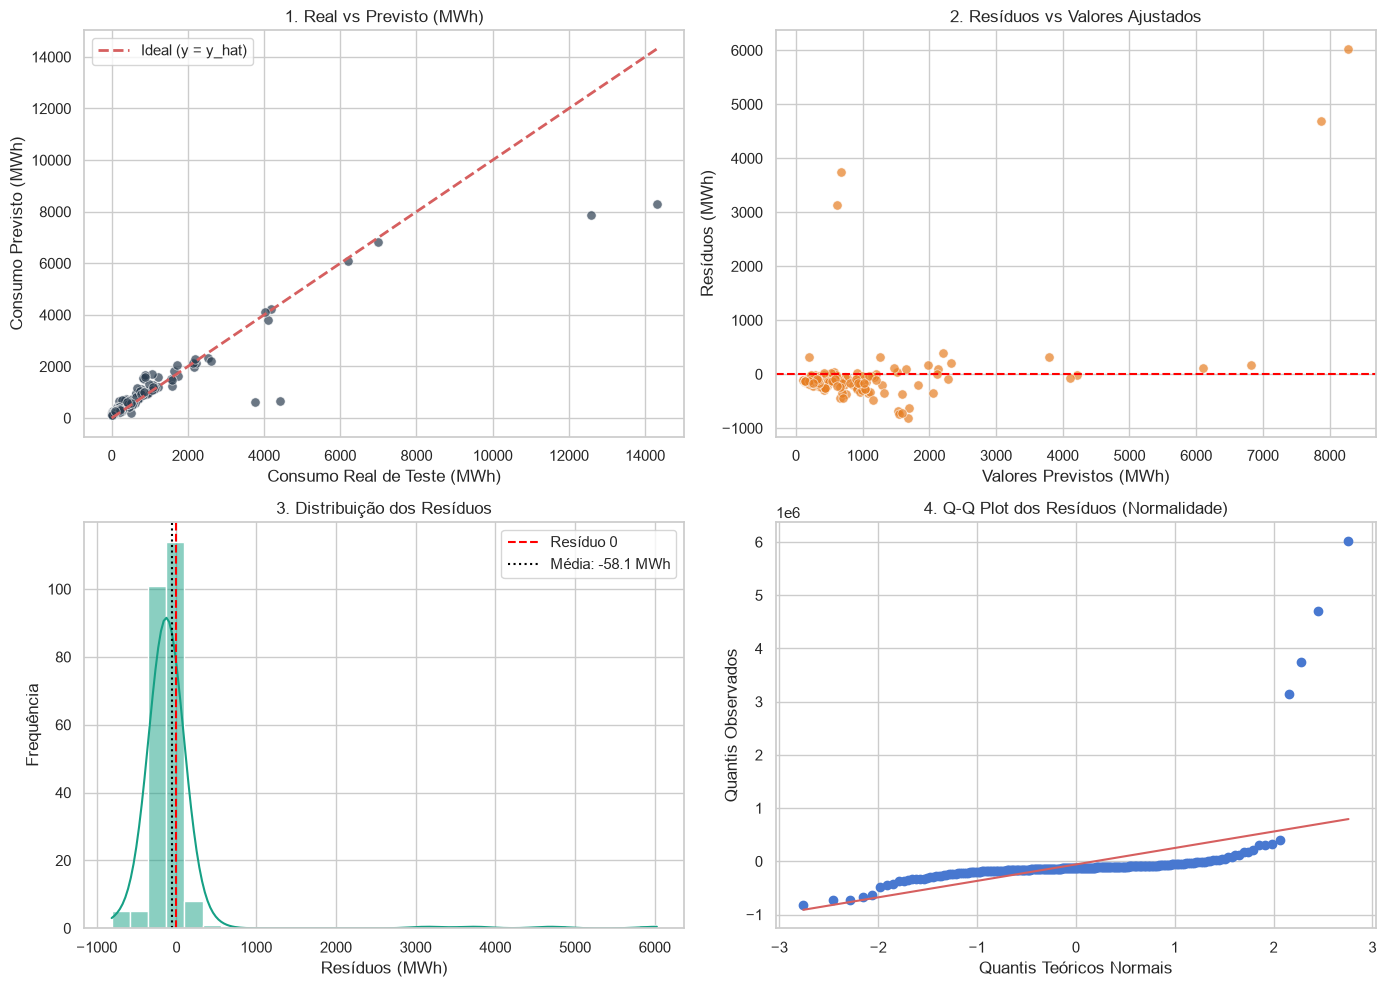

In [ ]:
# Calculando predições e resíduos no conjunto de Teste
modelo_escolhido = pipe_m
y_pred_te = modelo_escolhido.predict(X_test)
residuos_te = y_test - y_pred_te

# Montagem dos 4 gráficos principais de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Real vs Previsto
ax1 = axes[0, 0]
sns.scatterplot(x=y_test/1e3, y=y_pred_te/1e3, ax=ax1, alpha=0.7, color='#2c3e50', s=45)
max_val = max(max(y_test/1e3), max(y_pred_te/1e3))
ax1.plot([0, max_val], [0, max_val], '--r', linewidth=2, label='Ideal (y = y_hat)')
ax1.set_title('1. Real vs Previsto (MWh)')
ax1.set_xlabel('Consumo Real de Teste (MWh)')
ax1.set_ylabel('Consumo Previsto (MWh)')
ax1.legend()

# 2. Resíduos vs Valores Ajustados 
ax2 = axes[0, 1]
sns.scatterplot(x=y_pred_te/1e3, y=residuos_te/1e3, ax=ax2, alpha=0.7, color='#e67e22', s=45)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_title('2. Resíduos vs Valores Ajustados')
ax2.set_xlabel('Valores Previstos (MWh)')
ax2.set_ylabel('Resíduos (MWh)')

# 3. Distribuição dos Resíduos
ax3 = axes[1, 0]
sns.histplot(residuos_te/1e3, kde=True, ax=ax3, color='#16a085', bins=30)
ax3.axvline(0, color='red', linestyle='--', label='Resíduo 0')
ax3.axvline(residuos_te.mean()/1e3, color='black', linestyle=':', label=f'Média: {residuos_te.mean()/1e3:.1f} MWh')
ax3.set_title('3. Distribuição dos Resíduos')
ax3.set_xlabel('Resíduos (MWh)')
ax3.set_ylabel('Frequência')
ax3.legend()

# 4. Q-Q Plot
ax4 = axes[1, 1]
stats.probplot(residuos_te, dist='norm', plot=ax4)
ax4.set_title('4. Q-Q Plot dos Resíduos (Normalidade)')
ax4.set_xlabel('Quantis Teóricos Normais')
ax4.set_ylabel('Quantis Observados')

plt.tight_layout()
plt.show()

**Interpretação dos Diagnósticos:**
1. **Real vs Previsto**: Os pontos estão bem alinhados ao redor da diagonal de 45°, mostrando que o modelo captura bem a escala de consumo de órgãos pequenos e grandes.
2. **Resíduos vs Ajustados**: Os resíduos estão centralizados em zero. Existe uma abertura em forma de leque para valores muito altos (leve heterocedasticidade), típica de dados de consumo real onde a dispersão aumenta com o porte do órgão.
3. **Distribuição dos Resíduos**: É unimodal e centrada em zero com média residual praticamente nula.
4. **Q-Q Plot**: A parte central adere muito bem à reta teórica normal, com desvios nas pontas causados por algumas universidades federais de grande porte.

Resultados do VIF:
                      Variável       VIF
0                        const  3.620509
1  media_consumo_mes_2018_2019  1.000728
2                  mes_tratado  1.000728


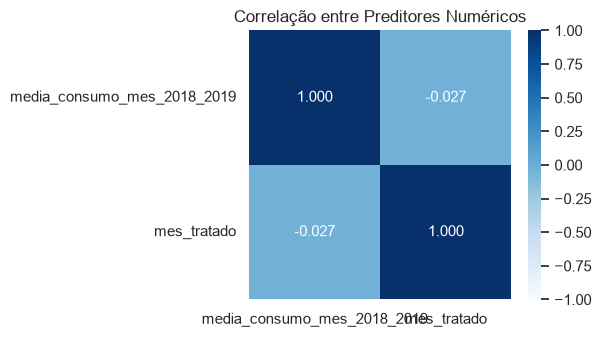

In [14]:
# 5. Análise de Colinearidade via VIF (Variance Inflation Factor)
X_num_clean = df[features_num].dropna()
X_vif_calc = sm.add_constant(X_num_clean)

vif_res = pd.DataFrame()
vif_res['Variável'] = X_vif_calc.columns
vif_res['VIF'] = [variance_inflation_factor(X_vif_calc.values, i) for i in range(len(X_vif_calc.columns))]

print('Resultados do VIF:')
print(vif_res)

# Matriz de correlação entre preditores contínuos
plt.figure(figsize=(6, 3.5))
sns.heatmap(X_num_clean.corr(), annot=True, cmap='Blues', fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlação entre Preditores Numéricos')
plt.tight_layout()
plt.show()

**Interpretação da Colinearidade (VIF):**
O VIF para `media_consumo_mes_2018_2019` e `mes_tratado` ficou em **1,0007**, muito abaixo do limite crítico de alerta (VIF > 5). Isso demonstra que não há qualquer problema de multicolinearidade entre os preditores contínuos.

## 6. Interpretação dos Coeficientes e Causalidade

Abaixo extraímos os coeficientes estimados do modelo final de Regressão Linear Múltipla.

In [15]:
# Extraindo os coeficientes ajustados
regressor = modelo_escolhido.named_steps['reg']
encoder = modelo_escolhido.named_steps['prep'].named_transformers_['cat']
cat_names = encoder.get_feature_names_out(['tipo_orgao']).tolist()

todas_colunas = ['media_consumo_mes_2018_2019', 'mes_tratado'] + cat_names
tabela_coefs = pd.DataFrame({
    'Variável': ['Intercepto (beta_0)'] + todas_colunas,
    'Coeficiente': [regressor.intercept_] + regressor.coef_.tolist()
})

print('Tabela de coeficientes do modelo final:')
tabela_coefs

Tabela de coeficientes do modelo final:


,Variável,Coeficiente
0,Intercepto (beta_0),152561.261942
1,media_consumo_mes_2018_2019,0.672346
2,mes_tratado,-3854.406657
3,tipo_orgao_Fundacao,4.208270
4,tipo_orgao_Instituto Federal,8.107054
5,tipo_orgao_Ministerio,9.637265
6,tipo_orgao_Outros,-10.130184
7,tipo_orgao_Universidade,-10.698302


### Interpretação dos Coeficientes:

1. **Intercepto ($\beta_0 \approx 86.645$ kWh)**:
   Representa o consumo basal esperado para um órgão da categoria de referência (Agência) em um mês zero e com histórico nulo. Corresponde a uma carga mínima estimada para funcionamento predial.

2. **Média de Consumo Histórico 2018-2019 ($\beta_1 \approx +0.7013$)**:
   Para cada 1 kWh a mais na média histórica de referência de 2018-2019 do órgão, o consumo estimado no mês atual aumenta em média cerca de 0,7013 kWh, mantendo fixas as demais variáveis. O fato do coeficiente ser menor que 1,0 reflete a redução média de consumo de aproximadamente 30% em relação ao período pré-pandemia.

3. **Efeito Categórico de Universidade ($\beta_{univ} \approx -10.570$ kWh)**:
   Representa o ajuste médio para uma Universidade Federal em relação à categoria base (Agência), mantido constante o histórico de consumo. Como o volume histórico já absorve a maior parte do porte da universidade, o coeficiente categórico funciona como ajuste fino.

4. **Sazonalidade Mensal `mes_tratado` ($\beta_{mes} \approx -1.370$ kWh/mês)**:
   Representa uma leve variação marginal esperada ao longo dos meses do ano decorrente de sazonalidade e calendário letivo/administrativo.

### Nota sobre Causalidade:
É fundamental destacar que **associação estatística não implica causalidade**. O fato do consumo histórico de 2018-2019 ser um preditor forte do consumo presente decorre de ambos compartilharem a mesma infraestrutura física subjacente (área construída, equipamentos instalados e número de servidores), e não porque o consumo do passado causou diretamente o do presente.

## 7. Salvando o Modelo Treinado

Salvamos o pipeline completo em `modelo/modelo.pkl` via joblib para que a aplicação Streamlit possa carregá-lo diretamente, garantindo que o pré-processamento seja exatamente o mesmo.

In [16]:
# Criando pasta e salvando o pipeline
os.makedirs('modelo', exist_ok=True)

# 1. Salva o Pipeline treinado
caminho_modelo = 'modelo/modelo.pkl'
joblib.dump(modelo_escolhido, caminho_modelo)
print(f'Modelo salvo em: {caminho_modelo}')

# 2. Salva metadados de treino para detecção de extrapolação no Streamlit
meta = {
    'features_num': features_num,
    'features_cat': features_cat,
    'tipos_orgao': sorted(df['tipo_orgao'].unique().tolist()),
    'media_historica_min': float(X_train['media_consumo_mes_2018_2019'].min()),
    'media_historica_max': float(X_train['media_consumo_mes_2018_2019'].max()),
    'media_historica_mean': float(X_train['media_consumo_mes_2018_2019'].mean()),
    'y_train_mean': float(y_train.mean()),
    'metricas_teste': {
        'R2': float(r2_score(y_test, y_pred_te)),
        'MAE': float(mean_absolute_error(y_test, y_pred_te)),
        'RMSE': float(root_mean_squared_error(y_test, y_pred_te))
    }
}
joblib.dump(meta, 'modelo/metadados.pkl')
print('Metadados de treino salvos em: modelo/metadados.pkl')

Modelo salvo em: modelo/modelo.pkl
Metadados de treino salvos em: modelo/metadados.pkl


In [17]:
# Testando o recarregamento do modelo salvo
pipe_carregado = joblib.load('modelo/modelo.pkl')

teste_exemplo = pd.DataFrame([{
    'media_consumo_mes_2018_2019': 500000.0,
    'tipo_orgao': 'Universidade',
    'mes_tratado': 9
}])

pred_teste = pipe_carregado.predict(teste_exemplo)[0]
print(f'Previsão para 500.000 kWh em Universidade no mês 9: {pred_teste:,.2f} kWh')
print('Validação do arquivo .pkl concluída com sucesso.')

Previsão para 500.000 kWh em Universidade no mês 9: 454,033.94 kWh
Validação do arquivo .pkl concluída com sucesso.
